# Genesis4 Plotting Examples

In [1]:
import h5py
import numpy as np

import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
c = 299792458.0
mec2  =510998.94999999995
# Or use:
#from  scipy.constants import physical_constants
#physical_constants['electron mass energy equivalent in MeV'][0]*1e6
with h5py.File('LCLS2_HXR_9keV.out.h5') as h5:
    power = h5["Field/power"][:]
    zplot = h5["Lattice/zplot"][:]
    ds_len = h5["Global/lambdaref"][0]*h5["Global/sample"][0]
    s_axis = np.arange(len(power[-1,:]))*ds_len
    power_max = np.max(power, 1)
    total_energy = np.sum(power[-1,:])*ds_len/c*1e3
    xsize = h5["Beam/xsize"][:]
    ysize = h5["Beam/ysize"][:]

In [3]:
print('The pulse energy is '+str(total_energy)+' mJ.')

The pulse energy is 0.04658080631088701 mJ.


Text(0, 0.5, 'Pulse Energy (mJ)')

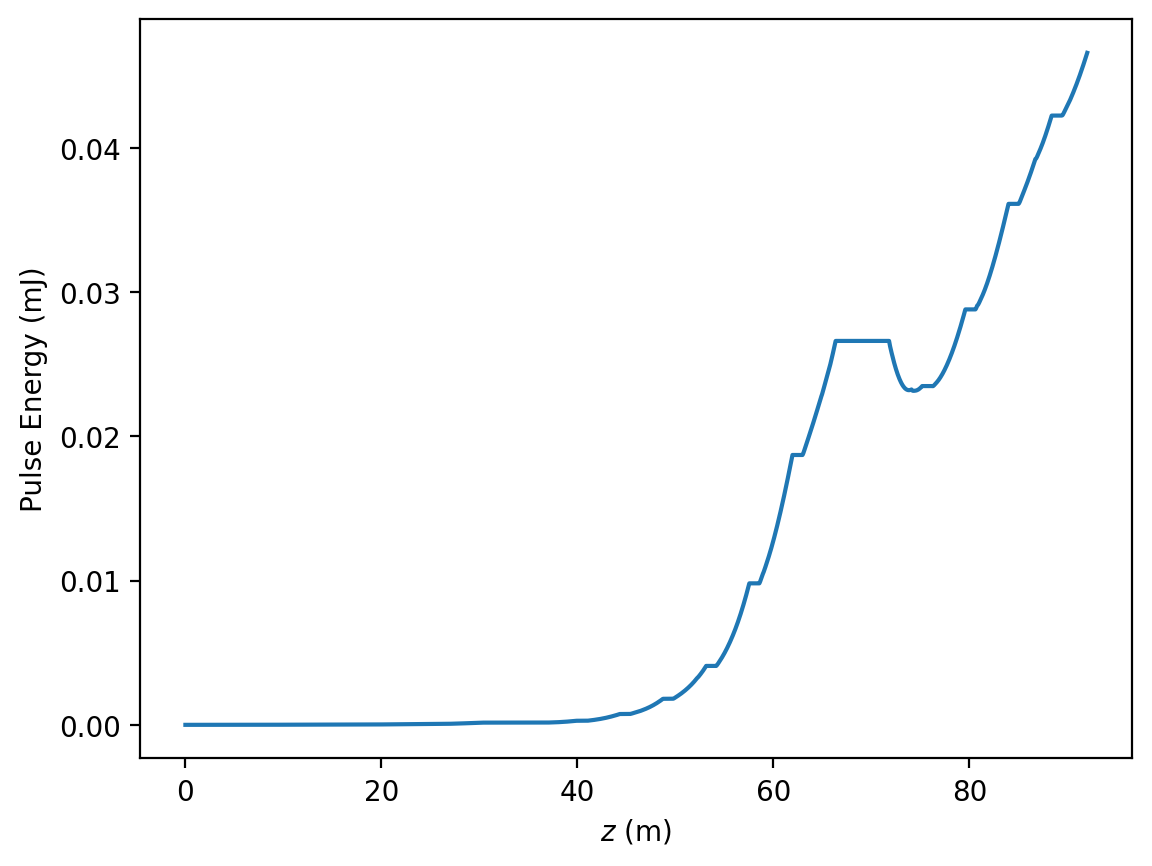

In [4]:
fig, ax = plt.subplots()
ax.plot(zplot, np.sum(power, axis =1)*ds_len/c*1e3)
ax.set_xlabel("$z$ (m)")
ax.set_ylabel("Pulse Energy (mJ)")

Text(0, 0.5, 'Peak Power (GW)')

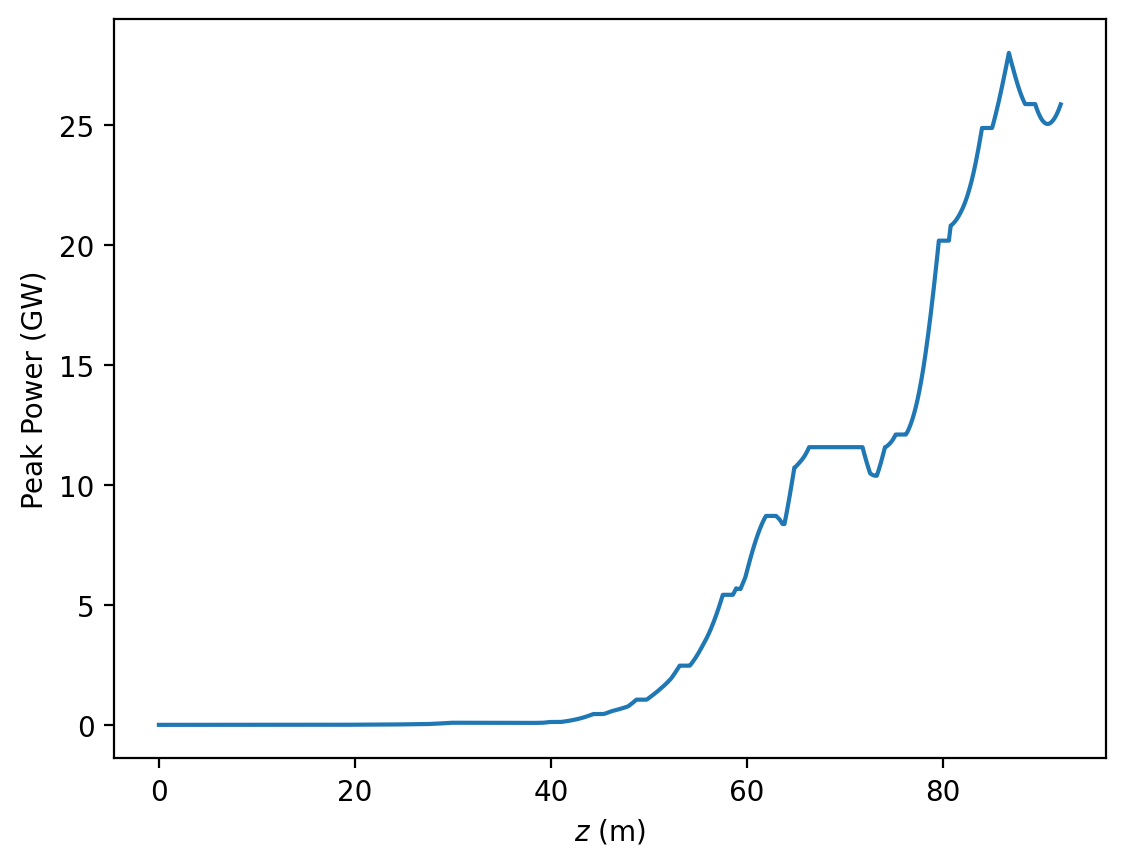

In [5]:
fig, ax = plt.subplots()
ax.plot(zplot, power_max*1e-9)
ax.set_xlabel("$z$ (m)")
ax.set_ylabel("Peak Power (GW)")

Text(0, 0.5, 'Power P (GW)')

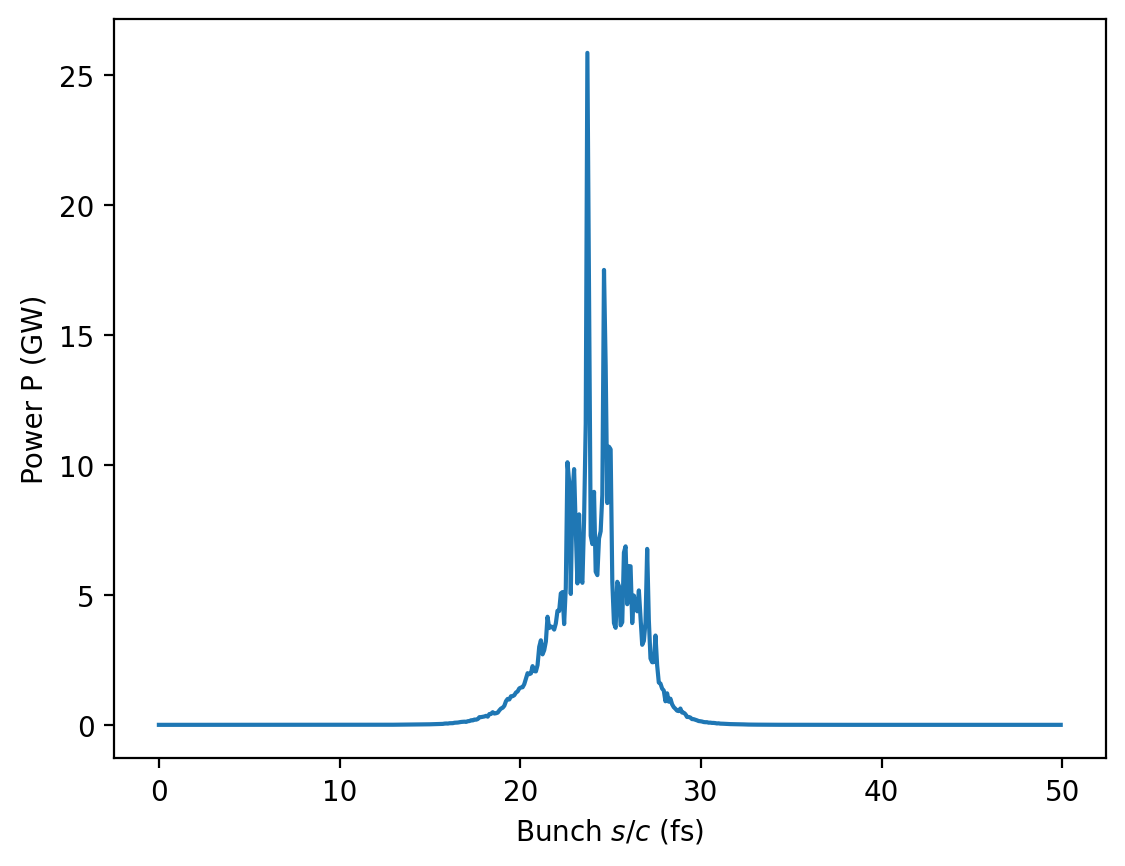

In [6]:
plt.plot(s_axis/3e8*1e15, power[-1,:]*1e-9)
plt.xlabel(r"Bunch $s/c$ (fs)")
plt.ylabel("Power P (GW)")

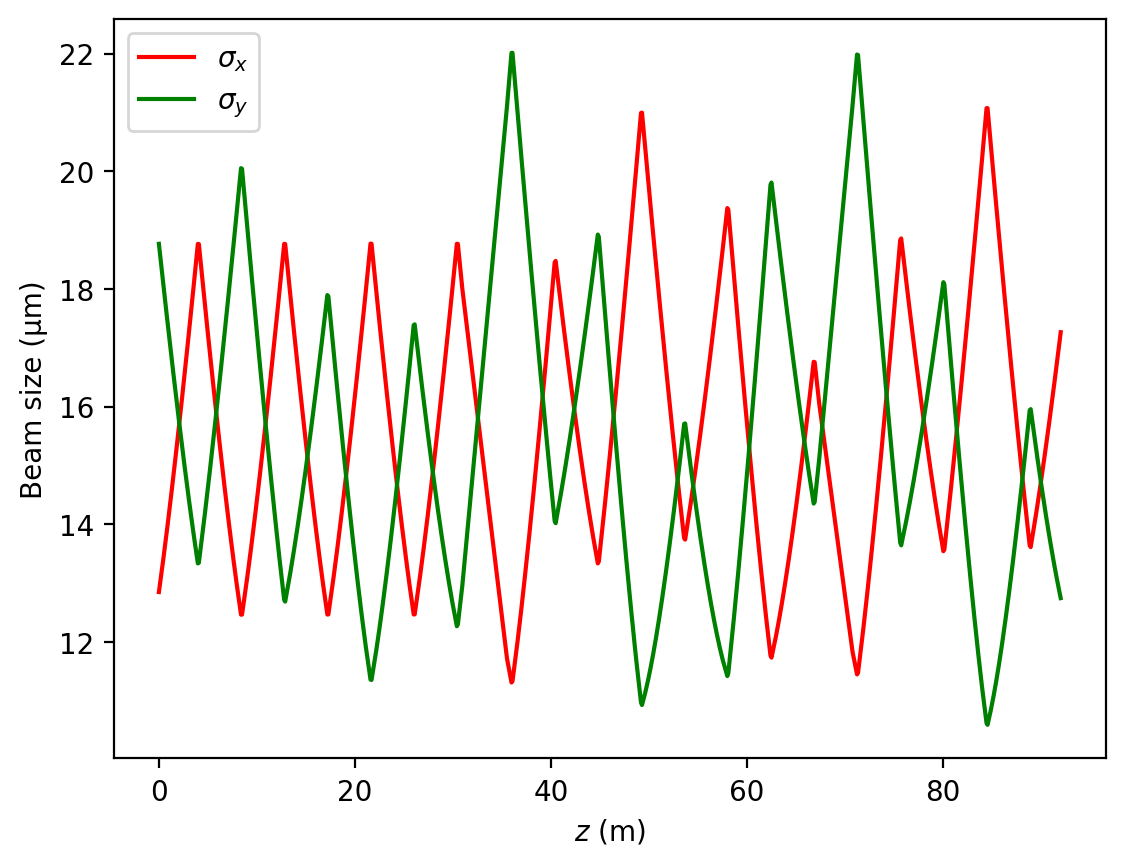

In [7]:
fig, ax = plt.subplots()

ax.plot(zplot, np.mean(xsize, axis=1)*1e6, label=r'$\sigma_x$', color='red')
ax.plot(zplot, np.mean(ysize, axis=1)*1e6, label=r'$\sigma_y$', color='green')
ax.set_xlabel("$z$ (m)")
ax.set_ylabel(r"Beam size (µm)")
plt.legend()